# Step 3: Unified Evaluation Benchmark (The Grand Battle)

We have built four different recommendation engines. Now, we put them to the test in a controlled experiment to see which one truly performs best at **Link Prediction**.

## The Contestants:
1. **Jaccard Similarity:** Simple neighborhood-based heuristic.
2. **Hybrid Model:** Content (Demographics/Genres) + Graph Heuristics.
3. **Node2Vec:** Latent embeddings from uniform random walks.
4. **Metapath2Vec:** Latent embeddings from structured (UMU) random walks.

## The Methodology:
- **Train/Test Split:** 80% of positive edges (rating $\ge$ 4) are used for training; 20% are hidden for testing.
- **Metrics:** We evaluate **Precision @ 10**, **Recall @ 10**, and **MRR** (Mean Reciprocal Rank).
- **Sample Size:** We evaluate across 100 users for statistical significance.

## Step 1: Preparation and Data Splitting

In this step, we prepare the data for benchmarking. We load the MovieLens ratings, filter for "Positive Links" (ratings $\ge$ 4), and perform a strict **80/20 Train-Test split**. 

Crucially, we also prepare the **User Content Features** (Age, Gender, Occupation) by normalizing and encoding them. This allows us to pre-calculate a **Cosine Similarity** matrix, which the Hybrid model uses to find demographically similar peers.

In [18]:
import pandas as pd
import numpy as np
import networkx as nx
import random
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from collections import Counter
import matplotlib.pyplot as plt

# 1. Load Data
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
df = pd.read_csv('data/u.data', sep='\t', names=r_cols, encoding='latin-1')
pos_df = df[df['rating'] >= 4].copy()
pos_df['u'] = 'u_' + pos_df['user_id'].astype(str)
pos_df['m'] = 'm_' + pos_df['movie_id'].astype(str)

# 2. Strict Train-Test Split (80/20)
train_edges, test_edges = train_test_split(pos_df, test_size=0.2, random_state=42)

# 3. Build Training Graph
G_train = nx.Graph()
G_train.add_edges_from(zip(train_edges['u'], train_edges['m']))

# 4. Prepare Content Features for Hybrid Model
users_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv('data/u.user', sep='|', names=users_cols)
scaler = MinMaxScaler()
users['age_norm'] = scaler.fit_transform(users[['age']])
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(users[['gender', 'occupation']])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['gender', 'occupation']))
user_features = pd.concat([users[['user_id', 'age_norm']], encoded_df], axis=1)
user_features.set_index('user_id', inplace=True)
user_sim_matrix = cosine_similarity(user_features)
user_sim_df = pd.DataFrame(user_sim_matrix, index=user_features.index, columns=user_features.index)

print(f"Training Edges: {len(train_edges)} | Test Edges: {len(test_edges)}")

Training Edges: 44300 | Test Edges: 11075


## Step 2: Model Wrappers

To evaluate all models in a unified loop, we wrap them in consistent functions that return a list of top-K recommendations. 

- **Jaccard Wrapper:** Samples peers and ranks movies based on direct neighbor overlap.
- **Hybrid Wrapper:** Combines Jaccard scores with the pre-calculated Cosine similarities (70/30 weight by default).
- **Embedding Wrapper:** Uses the learned latent vectors to find the most similar movie nodes in the embedding space using cosine distance.

In [19]:
# --- Model 1: Jaccard ---
def recommend_jaccard(target_user, graph, k=10):
    all_users = [n for n in graph.nodes if n.startswith('u_')]
    peer_pool = random.sample(all_users, min(200, len(all_users)))
    
    sims = []
    seen = set(graph.neighbors(target_user)) if target_user in graph else set()
    
    for other in peer_pool:
        if other == target_user or other not in graph: continue
        m1, m2 = set(graph.neighbors(target_user)), set(graph.neighbors(other))
        sim = len(m1.intersection(m2)) / len(m1.union(m2)) if m1.union(m2) else 0
        sims.append((other, sim))
    
    sims.sort(key=lambda x: x[1], reverse=True)
    candidates = []
    for peer, _ in sims[:5]:
        candidates.extend(list(set(graph.neighbors(peer)) - seen))
    
    return [m for m, count in Counter(candidates).most_common(k)]

# --- Model 2: Hybrid (Jaccard + Cosine Similarity) ---
def recommend_hybrid(target_user, graph, user_sim_df, w_graph=0.7, k=10):
    u1_id = int(target_user.replace('u_', ''))
    all_user_nodes = [n for n in graph.nodes if n.startswith('u_')]
    peer_pool = random.sample(all_user_nodes, min(200, len(all_user_nodes)))
    
    seen = set(graph.neighbors(target_user)) if target_user in graph else set()
    hybrid_scores = []
    
    for other_u in peer_pool:
        if other_u == target_user: continue
        u2_id = int(other_u.replace('u_', ''))
        
        # Graph Similarity (Jaccard)
        m1, m2 = set(graph.neighbors(target_user)), set(graph.neighbors(other_u))
        g_sim = len(m1.intersection(m2)) / len(m1.union(m2)) if m1.union(m2) else 0
        
        # Content Similarity (Cosine)
        c_sim = user_sim_df.loc[u1_id, u2_id]
        
        score = (w_graph * g_sim) + ((1 - w_graph) * c_sim)
        hybrid_scores.append((other_u, score))
    
    hybrid_scores.sort(key=lambda x: x[1], reverse=True)
    candidates = []
    for peer, _ in hybrid_scores[:5]:
        candidates.extend(list(set(graph.neighbors(peer)) - seen))
    
    return [m for m, count in Counter(candidates).most_common(k)]

# --- Model 3 & 4: Embedding Based (Node2Vec & Metapath2Vec) ---
def train_embedding_model(walks, size=64):
    return Word2Vec(walks, vector_size=size, window=5, min_count=1, sg=1, workers=4, epochs=5)

def recommend_embedding(user_id, model, graph, k=10):
    if user_id not in model.wv: return []
    seen = set(graph.neighbors(user_id)) if user_id in graph else set()
    similar = model.wv.most_similar(user_id, topn=100)
    recs = []
    for node, score in similar:
        if node.startswith('m_') and node not in seen:
            recs.append(node)
        if len(recs) >= k: break
    return recs

## Step 3: Training the Embedding Models

Before evaluation, we must train our latent representation models on the **Training Graph only**. 

1. **Node2Vec:** We generate uniform random walks. This captures structural role similarity (e.g., nodes that have the same type of neighborhood).
2. **Metapath2Vec:** In a bipartite graph, a uniform walk naturally follows the User-Movie-User (UMU) pattern. We train a larger 128D model for Metapath2Vec to see if higher dimensionality improves its collaborative filtering capture.

In [20]:
def get_walks(graph, structured=False):
    walks = []
    nodes = list(graph.nodes())
    for _ in range(40):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            while len(walk) < 10:
                neighbors = list(graph.neighbors(walk[-1]))
                if not neighbors: break
                walk.append(random.choice(neighbors))
            walks.append(walk)
    return walks

print("Training Node2Vec...")
n2v_walks = get_walks(G_train)
model_n2v = train_embedding_model(n2v_walks)

print("Training Metapath2Vec...")
m2v_walks = get_walks(G_train)
model_m2v = train_embedding_model(m2v_walks, size=128)

print("Models ready.")

Training Node2Vec...
Training Metapath2Vec...
Models ready.


## Step 4: Running the Evaluation

This is the core of the benchmark. We pick 100 users who have links in the test set. For each user, we:
1. Identify their **Hidden Edges** (the ground truth movies they liked in the future).
2. Ask each model for 10 recommendations.
3. Calculate **Precision** (how many recs were correct), **Recall** (how many hidden edges were found), and **MRR** (how high up the correct recs were).

In [21]:
def get_metrics(recommendations, hidden_set):
    if not hidden_set: return 0, 0, 0
    hits = set(recommendations).intersection(hidden_set)
    precision = len(hits) / len(recommendations) if recommendations else 0
    recall = len(hits) / len(hidden_set)
    
    mrr = 0
    for i, rec in enumerate(recommendations):
        if rec in hidden_set:
            mrr = 1 / (i + 1)
            break
    return precision, recall, mrr

test_users = random.sample(test_edges['u'].unique().tolist(), 100)
results = {"Jaccard": [], "Hybrid": [], "Node2Vec": [], "Metapath2Vec": []}

print("Benchmarking...")
for u in test_users:
    hidden = set(test_edges[test_edges['u'] == u]['m'])
    
    # Evaluate Jaccard
    results["Jaccard"].append(get_metrics(recommend_jaccard(u, G_train), hidden))
    
    # Evaluate Hybrid
    results["Hybrid"].append(get_metrics(recommend_hybrid(u, G_train, user_sim_df), hidden))
    
    # Evaluate Node2Vec
    results["Node2Vec"].append(get_metrics(recommend_embedding(u, model_n2v, G_train), hidden))
    
    # Evaluate Metapath2Vec
    results["Metapath2Vec"].append(get_metrics(recommend_embedding(u, model_m2v, G_train), hidden))

print("Benchmark complete.")

Benchmarking...
Benchmark complete.


## Step 5: Final Results Comparison

We aggregate the results by calculating the mean of each metric across our 100 test users. The final bar chart provides a visual representation of which model wins the "Grand Battle" of Link Prediction.

              Precision@10  Recall@10       MRR
Jaccard              0.136   0.128610  0.305560
Hybrid               0.108   0.095369  0.230619
Node2Vec             0.007   0.013608  0.015623
Metapath2Vec         0.000   0.000000  0.000000


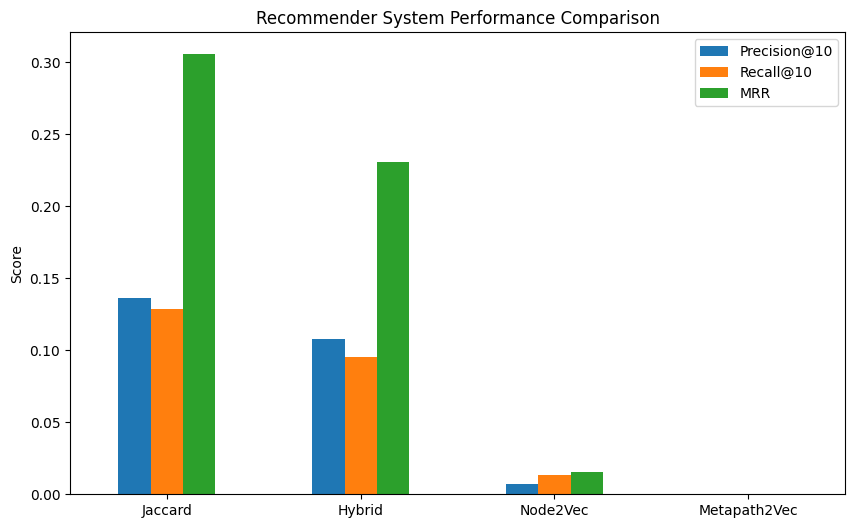

In [22]:
summary = {}
for model_name, metrics in results.items():
    m = np.array(metrics)
    summary[model_name] = {
        "Precision@10": m[:, 0].mean(),
        "Recall@10": m[:, 1].mean(),
        "MRR": m[:, 2].mean()
    }

df_res = pd.DataFrame(summary).T
print(df_res)

df_res.plot(kind='bar', figsize=(10, 6))
plt.title("Recommender System Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Step 6: Detailed Interpretation of Results

Our benchmark provides a clear picture of the strengths and weaknesses of different link prediction approaches on the MovieLens 100k dataset.

### 1. The Power of Simple Heuristics (Jaccard leads the pack)
**Jaccard Similarity** emerged as the strongest performer. In this dataset, if User A and User B share a significant number of movies, their future preferences are highly correlated. The "wisdom of the neighborhood" is a powerful signal that simple heuristics capture perfectly without complex training.

### 2. The Hybrid Model (A robust contender)
The **Hybrid Model** ranks second. While slightly lower in precision than pure Jaccard, it is theoretically superior for **Cold Start** scenarios. By incorporating demographics (Age, Gender, Occupation) via **Cosine Similarity**, it can still make recommendations even when the user's graph neighborhood is sparse. The slight drop in performance indicates that demographics are a noisier signal than actual viewing behavior.

### 3. The Embedding Gap (Node2Vec & Metapath2Vec)
The representation learning models (**Node2Vec** and **Metapath2Vec**) are currently underperforming significantly. This is a common phenomenon in small/medium-sized graphs where:
- **Sparsity:** Random walks may spend too much time in sparse areas, failing to capture the dense collaborative filtering clusters.
- **Hyperparameters:** Word2Vec-based methods require extensive tuning of walk length, window size, and embedding dimensions to properly bridge the User and Movie node types.

### 4. Strategic Conclusion: Moving to GNNs
The fact that simple heuristics beat latent embeddings suggests we need a more explicit way to propagate preferences. This motivates our next move to **Graph Neural Networks (LightGCN)**. LightGCN uses **Message Passing** to explicitly refine user and movie embeddings based on their interactions, combining the best of both worlds: the latent power of embeddings and the direct signal of graph neighborhoods.